In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'


dataset = pd.read_csv(url, names = ['sepal_length','sepal_width','petal_length','petal_width','Class'],index_col=None)
dataset

,sepal_length,sepal_width,petal_length,petal_width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [44]:
X = dataset.drop('Class',axis=1)
y = dataset['Class']

In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

In [46]:
#le = LabelEncoder()

#y = le.fit_transform(y)

In [47]:
y

,Class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


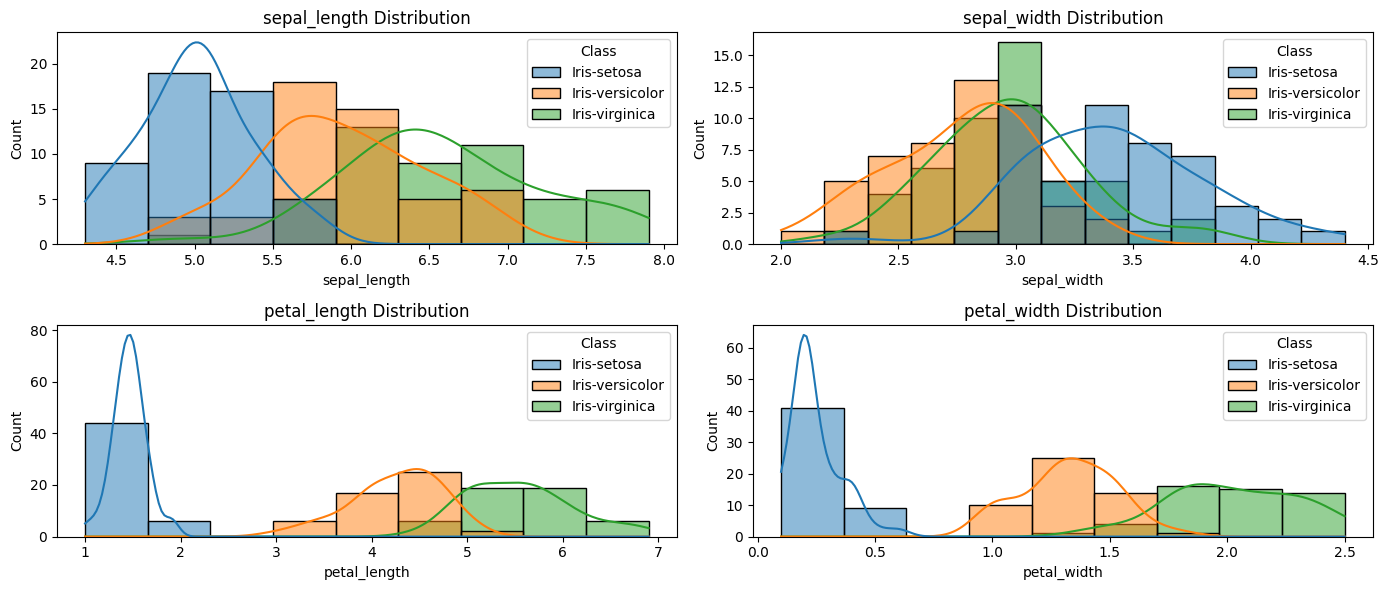

In [48]:
plt.figure(figsize=(14,6))

for i, feature in enumerate(['sepal_length','sepal_width','petal_length','petal_width']):
  plt.subplot(2,2,i+1)
  sns.histplot(data=dataset, x=feature, hue='Class',kde=True)
  plt.title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

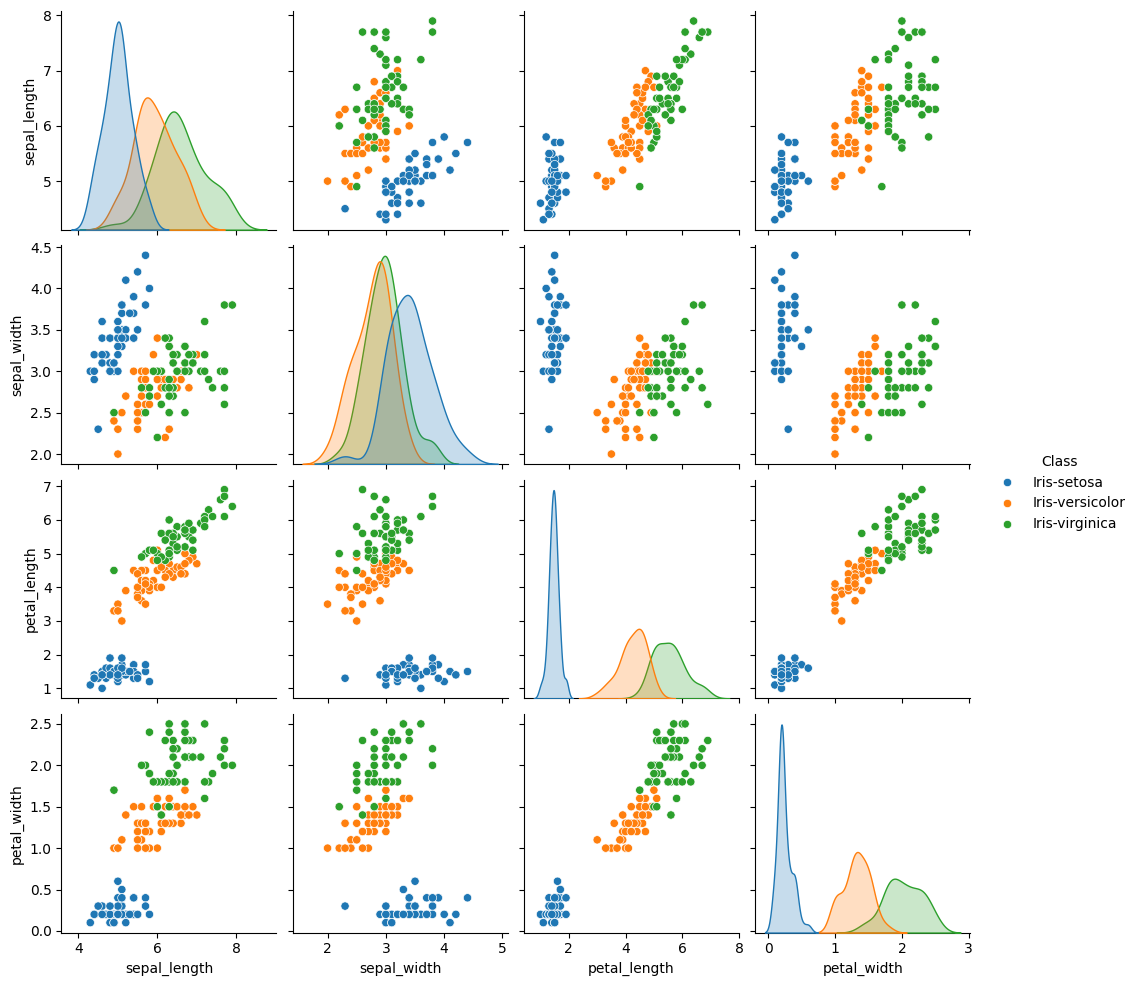

In [49]:
#pairplot


sns.pairplot(dataset,hue='Class')

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [57]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_train = lda.fit_transform(X_train, y_train)
X_test = lda.transform(X_test)

In [58]:
X_train

array([[-7.58097992e+00, -6.41880991e-01],
       [ 6.44248165e+00,  2.41239112e-01],
       [ 7.47595258e-01, -1.72746099e+00],
       [-7.39894386e+00, -8.50846631e-01],
       [-8.64292391e-02, -7.35704735e-01],
       [ 1.26364103e+00, -1.65372171e+00],
       [-6.19098140e+00,  5.21284494e-01],
       [ 5.65483033e+00, -1.27117493e-01],
       [-8.34582630e+00,  5.91061255e-01],
       [ 4.30708868e-01, -1.53028229e+00],
       [ 6.50308552e+00, -1.56896264e+00],
       [ 1.46811102e+00, -1.26003345e+00],
       [-7.39894386e+00, -8.50846631e-01],
       [-7.79750488e+00,  6.53498381e-02],
       [ 2.23073971e+00, -4.48057107e-01],
       [-7.35955730e+00,  4.70762316e-01],
       [ 1.80838157e+00,  3.54015530e-01],
       [ 9.45310561e+00, -1.04642700e+00],
       [ 6.52809928e+00,  2.27962580e+00],
       [ 2.77810648e+00, -3.62381999e-02],
       [-9.98956507e+00,  1.61045194e+00],
       [ 2.66116342e+00, -2.66600429e-01],
       [-6.89001344e+00, -5.52062906e-01],
       [ 5.

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [55]:
confusion_matrix(y_pred,y_test)

array([[13,  0,  0],
       [ 0, 20,  0],
       [ 0,  0, 12]])